### Initial Data Plotting

Dropped 173 rows due to missing data.
Final dataset has 1055 complete observations.
Data cleaning and preparation complete.


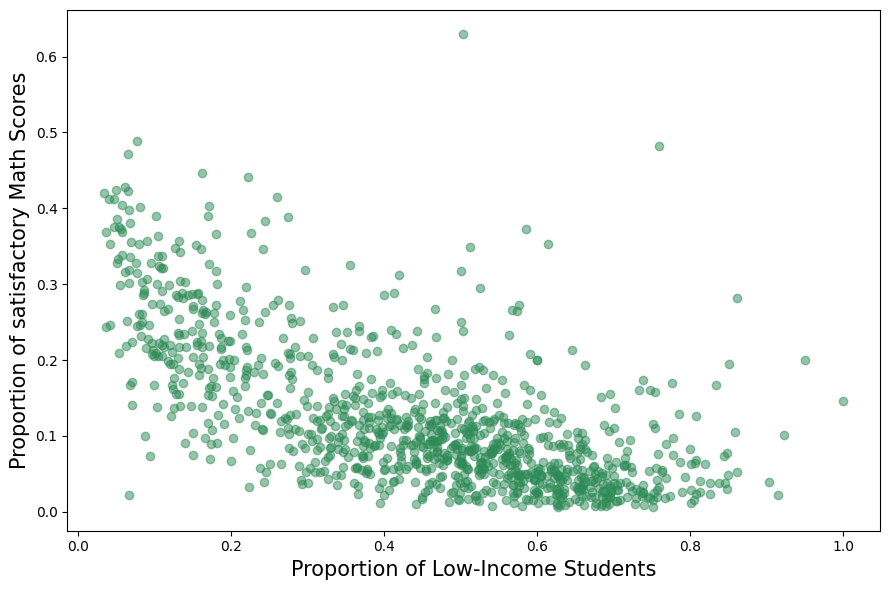

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sts

def clean_and_prepare_data(raw_file_path):
    """
    Loads the raw APRENDER dataset, cleans the necessary columns,
    engineers new variables for the predictive model, and returns a
    cleaned pandas DataFrame.
    """

    df = pd.read_csv(raw_file_path, delimiter=';', encoding='latin-1')

    def clean_numeric(series):
        if series.dtype == 'object':
            series = series.str.replace(',', '.', regex=False)
        return pd.to_numeric(series, errors='coerce')

    # columns to be extracted
    math_cols = [
        'mdesemp_Por_debajo_del_nivel_básico', 'mdesemp_Básico',
        'mdesemp_Satisfactorio'
    ]

    nse_cols = [
        'NSE_Quintiles_Q1', 'NSE_Quintiles_Q2', 'NSE_Quintiles_Q3',
        'NSE_Quintiles_Q4', 'NSE_Quintiles_Q5'
    ]

    all_cols_to_clean = math_cols + nse_cols
    df_clean = pd.DataFrame()

    # clean the columns we need
    for col in all_cols_to_clean:
        if col in df.columns:
            df_clean[col] = clean_numeric(df[col])
        else:
            print(f"Warning: Column '{col}' not found in source file.")

    # outcome: the proportion of students who are Satisfactory'
    df_clean['total_estudiantes_math'] = df_clean[math_cols].sum(axis=1)
    df_clean['pct_satisfactorio'] = (
        df_clean['mdesemp_Satisfactorio'] / df_clean['total_estudiantes_math']
    )

    # predictor: proportion of students in the lowest two socioeconomic quintiles
    df_clean['total_nse_resp'] = df_clean[nse_cols].sum(axis=1)
    df_clean['pct_nse_bajo'] = (
        (df_clean.get('NSE_Quintiles_Q1', 0) + df_clean.get('NSE_Quintiles_Q2', 0)) /
         df_clean['total_nse_resp']
    )

    # finalize dataframe
    final_model_vars = ['pct_satisfactorio', 'pct_nse_bajo']
    df_model_ready = df_clean[final_model_vars].copy()

    # replace inf values (from division by zero) with NaN
    df_model_ready.replace([np.inf, -np.inf], np.nan, inplace=True)

    # drop any rows where our key variables could not be calculated (NaN)
    original_rows = len(df_model_ready)
    df_model_ready = df_model_ready.dropna()
    final_rows = len(df_model_ready)

    print(f"Dropped {original_rows - final_rows} rows due to missing data.")
    print(f"Final dataset has {final_rows} complete observations.")

    # return cleaned dataframe
    print("Data cleaning and preparation complete.")
    return df_model_ready

RAW_DATA_FILE = "2024 Base APRENDER - Censal - Secundaria 5-6 año - Agregada - Desempeños de Matematica(in).csv"

# Run the cleaning function and store the result in 'df_cleaned'
df_cleaned = clean_and_prepare_data(RAW_DATA_FILE)

if df_cleaned is not None:
    plt.figure(figsize=(9, 6))
    plt.scatter(df_cleaned['pct_nse_bajo'], df_cleaned['pct_satisfactorio'], color="seagreen", alpha=0.5)
    plt.xlabel('Proportion of Low-Income Students', fontsize=15)
    plt.ylabel('Proportion of satisfactory Math Scores', fontsize=15)
    plt.tight_layout()
    plt.show()

else:
    print("Data cleaning failed. Cannot generate plots.")



In [2]:
df = pd.read_csv("2024 Base APRENDER - Censal - Secundaria 5-6 año - Agregada - Desempeños de Matematica(in).csv", delimiter=';', encoding='latin-1')
def clean_numeric(series):
  if series.dtype == 'object':
      series = series.str.replace(',', '.', regex=False)
  return pd.to_numeric(series, errors='coerce')

avanzado_col_cleaned = clean_numeric(df['mdesemp_Avanzado'])
nan_count = avanzado_col_cleaned.isna().sum()

print(f"--- CHECK: Number of NaNs in 'mdesemp_Avanzado' column: {nan_count} ---")
print(f"--- CHECK: Total rows in file: {len(df)} ---")

--- CHECK: Number of NaNs in 'mdesemp_Avanzado' column: 1228 ---
--- CHECK: Total rows in file: 1228 ---


## Setting up the model

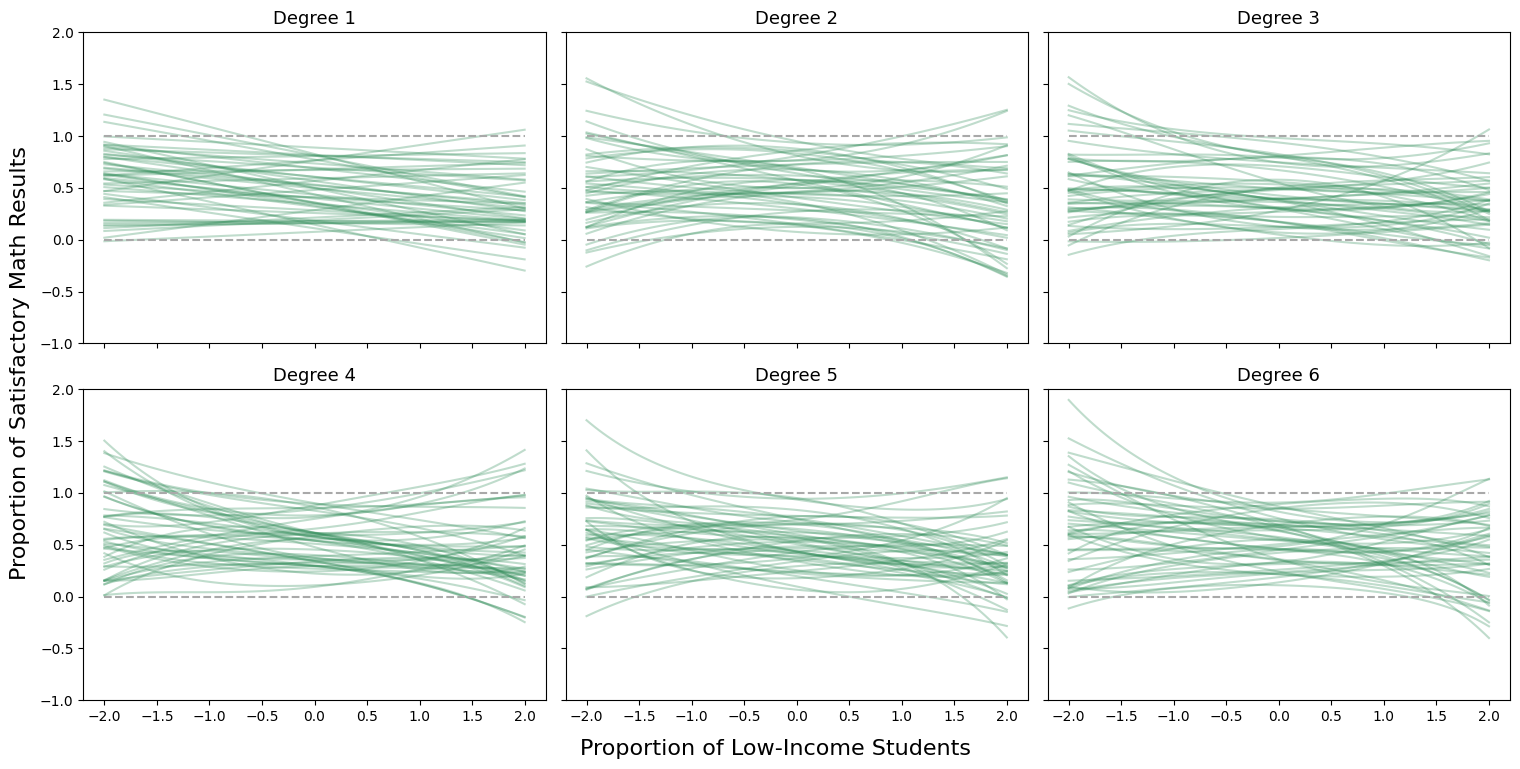

In [3]:
# prior predictive plots
a_prior = sts.beta(2, 2)
num_lines = 50
x_pred_points = np.linspace(-2, 2, 100)


# b priors
b_priors_deg1 = [
    sts.norm(loc=-0.05, scale=0.1)
]
b_priors_deg2 = b_priors_deg1 + [
    sts.norm(loc=0, scale=0.05)
]
b_priors_deg3 = b_priors_deg2 + [
    sts.norm(loc=0, scale=0.01)
]
b_priors_deg4 = b_priors_deg3 + [
    sts.norm(loc=0, scale=0.005)
]
b_priors_deg5 = b_priors_deg4 + [
    sts.norm(loc=0, scale=0.001)
]
b_priors_deg6 = b_priors_deg5 + [
    sts.norm(loc=0, scale=0.0005)
]

# list to iterate through
all_b_priors_lists = [b_priors_deg1, b_priors_deg2, b_priors_deg3, b_priors_deg4, b_priors_deg5, b_priors_deg6]


def plot_prior_mean_lines(ax, a_prior, b_priors_list, num_lines, x_pred_points):
    """
    Generates and plots prior mean trend lines (mu) for a polynomial model
    on a specific matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object to plot on.
        a_prior (scipy.stats.rv_continuous): The distribution for 'a'.
        b_priors_list (list): A list of scipy.stats priors, one for each 'b'.
        num_lines (int): The number of lines to sample and plot.
        x_pred_points (np.ndarray): 1D array of x-values to evaluate at.

    Returns:
        np.ndarray: 2D array of mu values.
    """
    # degree is now inferred from the length of the list
    degree = len(b_priors_list)
    # prior samples
    a_samples = a_prior.rvs(num_lines)
    b_samples_list = []
    for prior in b_priors_list:
        b_samples_list.append(prior.rvs(size=num_lines))
    # array for easier plotting
    b_samples_array = np.stack(b_samples_list, axis=1)

    # create mu-lines depending on the degree
    x_poly = np.stack([x_pred_points**i for i in range(1, degree + 1)], axis=1)

    # calculate mu using matrix multiplication
    mu_lines = a_samples[:, np.newaxis] + np.dot(b_samples_array, x_poly.T)

    # plot on the specific axis passed to the function
    for line in mu_lines:
        ax.plot(x_pred_points, line, color='seagreen', alpha=0.3)
    ax.set_ylim(-1,2)
    ax.set_title(f"Degree {degree}", fontsize=13)
    ax.hlines(0, -2,2, color='darkgrey', linestyles="dashed", alpha=1)
    ax.hlines(1, -2,2, color='darkgrey', linestyles="dashed", alpha=1)
    return mu_lines

# create plot with all prior predictives
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()
for current_ax, b_priors in zip(axes_flat, all_b_priors_lists):
    plot_prior_mean_lines(
        current_ax,
        a_prior,
        b_priors,
        num_lines,
        x_pred_points
    )
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
fig.text(0.5, 0.01, 'Proportion of Low-Income Students', ha='center', fontsize=16)
fig.text(-0.01, 0.5, 'Proportion of Satisfactory Math Results', va='center', rotation='vertical', fontsize=16)
plt.show()



In [32]:
math_scores = df_cleaned['pct_satisfactorio']
low_inc_perc_s = (df_cleaned['pct_nse_bajo'] - df_cleaned['pct_nse_bajo'].mean()) / df_cleaned['pct_nse_bajo'].std()

print(min(low_inc_perc_s), max(low_inc_perc_s))
# create all polynomial terms
low_inc_perc2_s = low_inc_perc_s**2
low_inc_perc3_s = low_inc_perc_s**3
low_inc_perc4_s = low_inc_perc_s**4
low_inc_perc5_s = low_inc_perc_s**5
low_inc_perc6_s = low_inc_perc_s**6

-1.9828994859867852 2.721087752885053


Output()

Output()

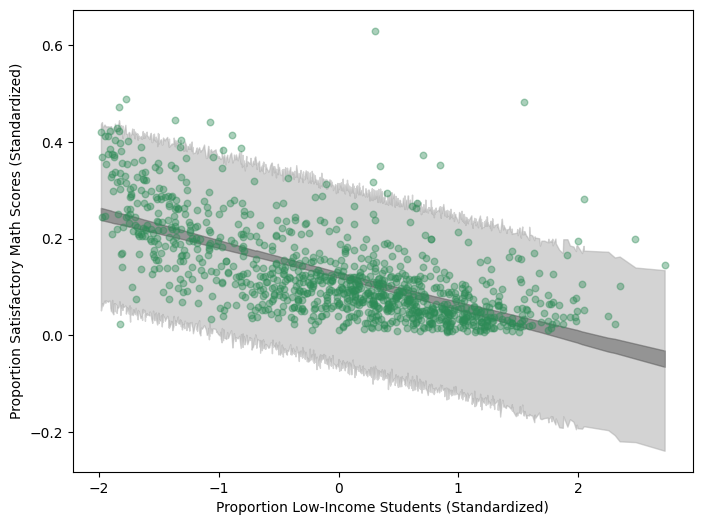

In [5]:
import pymc as pm
import arviz as az

math_scores = df_cleaned['pct_satisfactorio']

with pm.Model() as m_1_1:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    prior_pred_linear = pm.sample_prior_predictive()
    trace_1_1 = pm.sample(chains=4, tune=1000, target_accept=0.9)

mu_pred_1_1 = trace_1_1.posterior["mu"]
with m_1_1:
    math_pred_1_1 = pm.sample_posterior_predictive(trace_1_1)


plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_1_1, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_1_1.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.plot([],[], color="darkgrey", label="μ")
plt.plot([],[], color="lightgrey", label="89% Interval of μ")
plt.xlabel("Proportion Low-Income Students (Standardized)")
plt.ylabel("Proportion Satisfactory Math Scores (Standardized)")
plt.show()

In [6]:
varnames = ["~mu"]
az.summary(trace_1_1, varnames)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.125,0.002,0.120,0.129,0.0,0.0,4432.0,2793.0,1.0
b1,-0.064,0.002,-0.068,-0.060,0.0,0.0,3974.0,3077.0,1.0
sigma,0.072,0.002,0.069,0.075,0.0,0.0,4335.0,2861.0,1.0


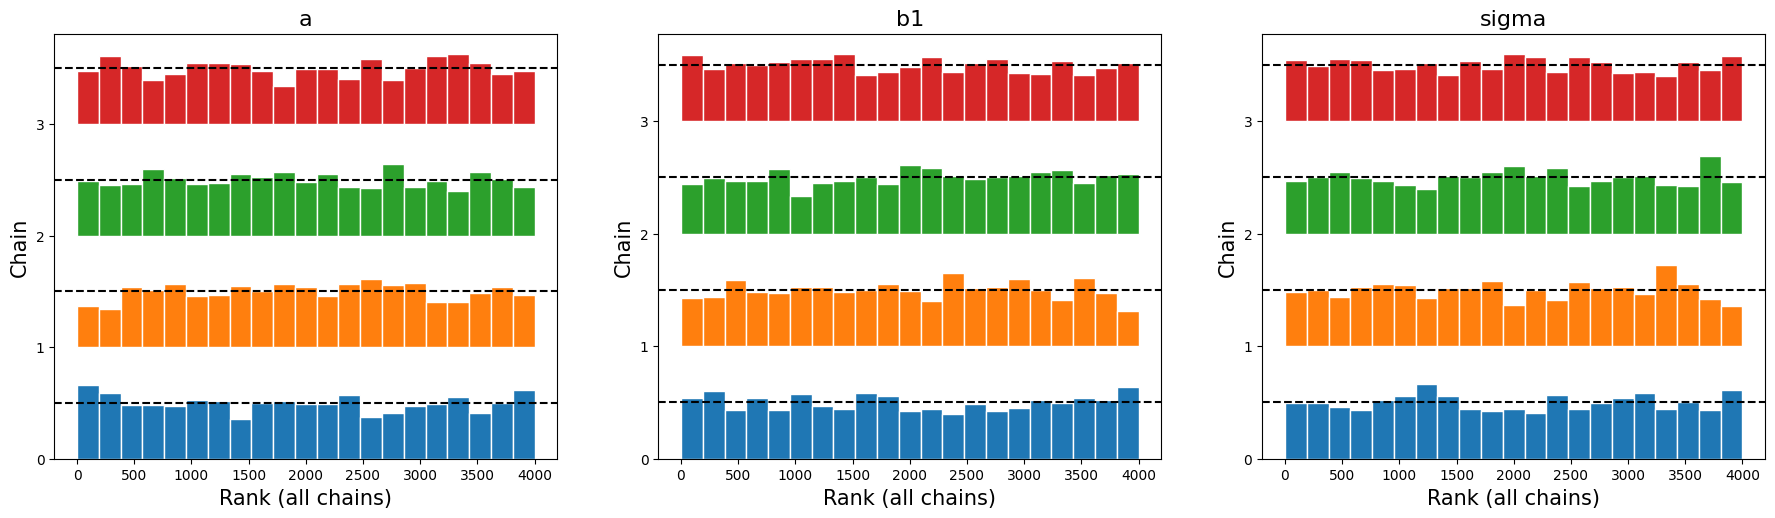

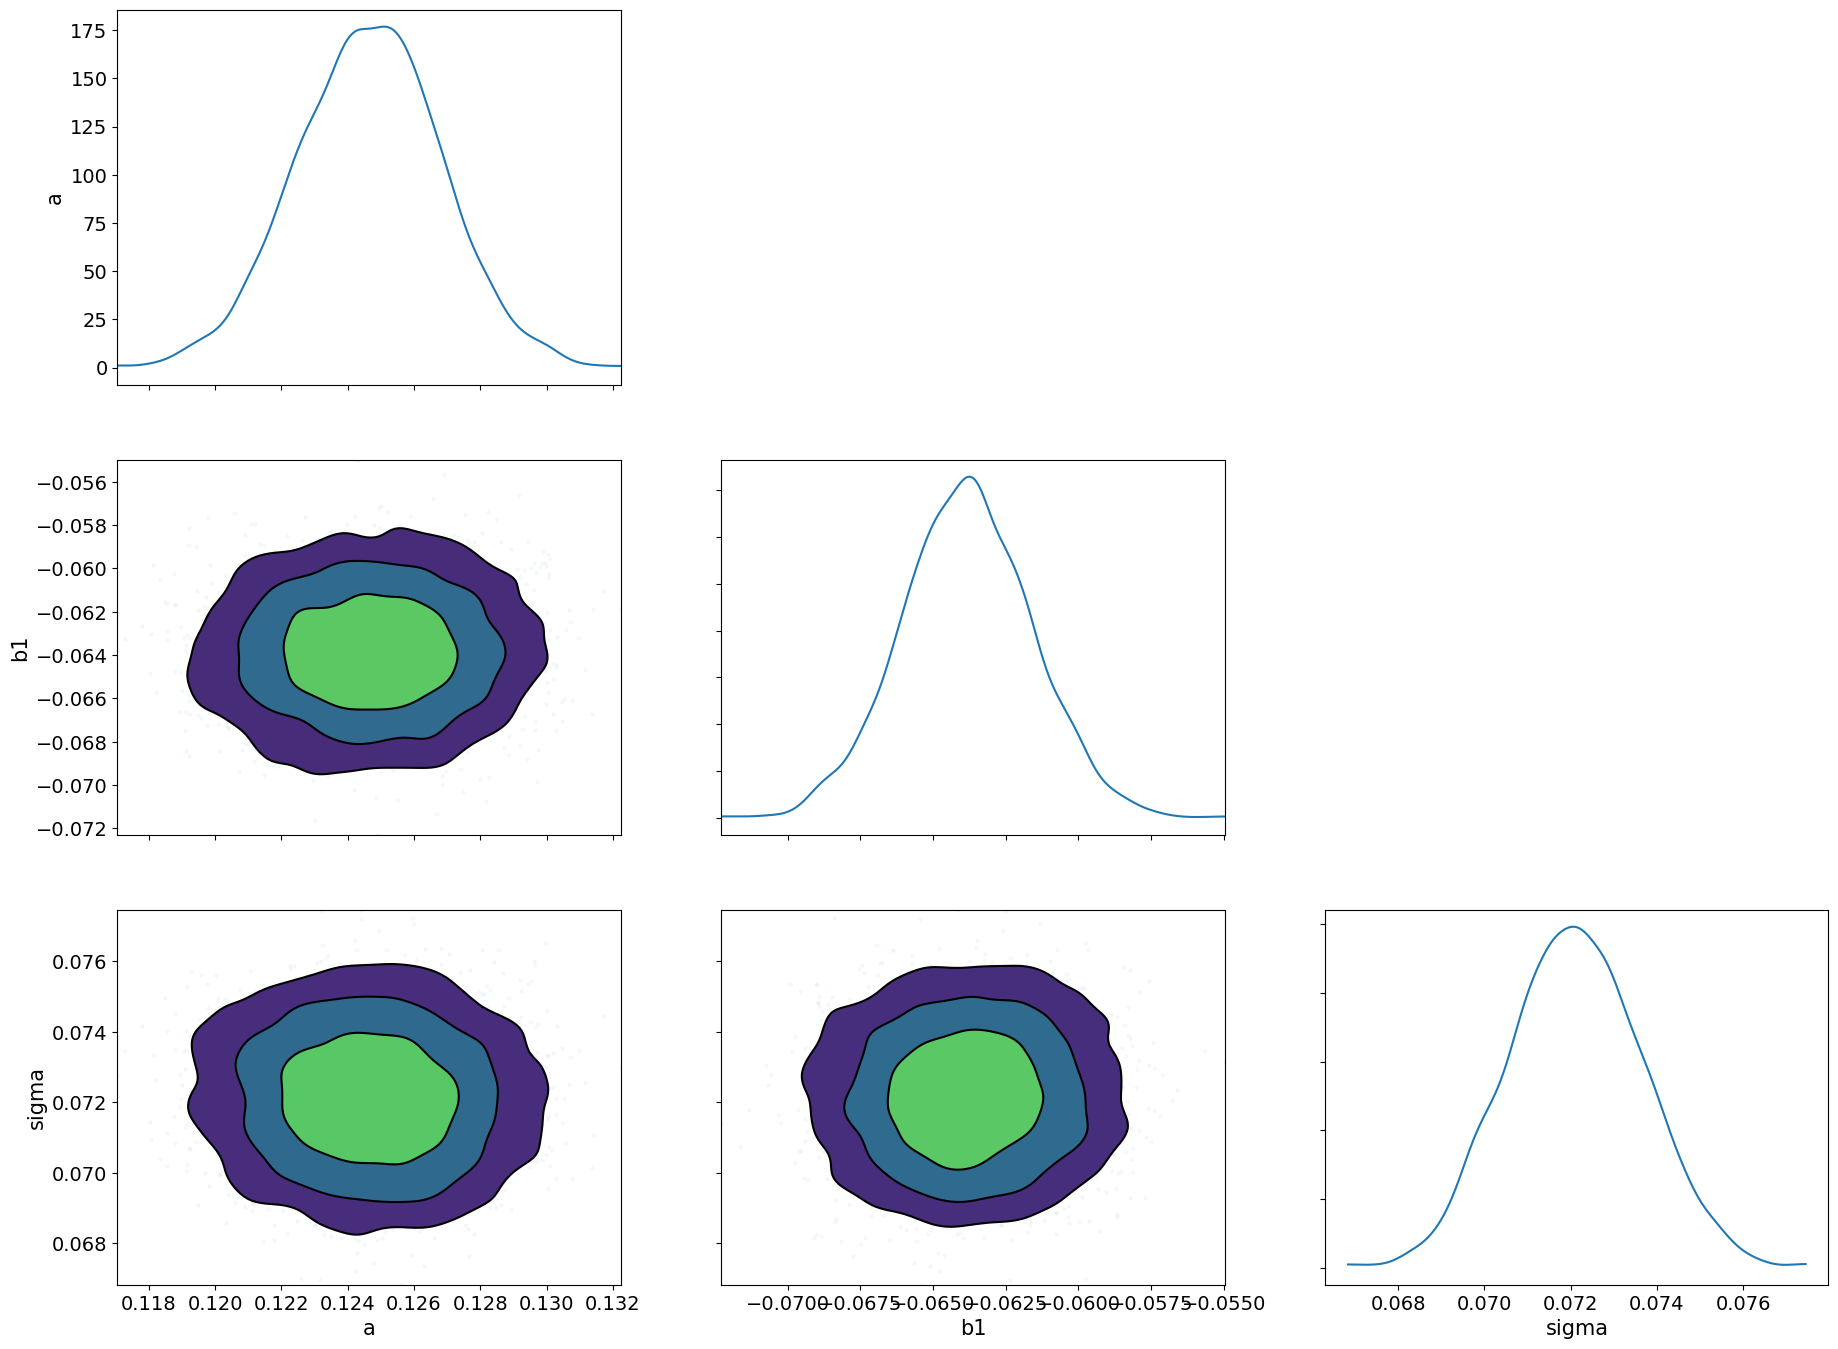

In [7]:
# we have a different mu for every datapoint
az.plot_rank(trace_1_1, varnames)
ax = az.plot_pair(
    trace_1_1,
    var_names=varnames,
    marginals=True,
    kind=["scatter", "kde"],
    scatter_kwargs={"color": "C0", "alpha": 0.05},
    marginal_kwargs={"kind": "kde", "color": "C0"},
    kde_kwargs={"contour_kwargs": {"colors": "k", 'alpha': 1}});

## Model 2

In [8]:
with pm.Model() as m_1_2:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    trace_1_2 = pm.sample(chains=4, tune=1000, target_accept=0.9)

Output()

In [9]:
az.summary(trace_1_2, varnames)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.101,0.003,0.096,0.106,0.0,0.0,3003.0,2941.0,1.0
b1,-0.060,0.002,-0.064,-0.056,0.0,0.0,3316.0,2313.0,1.0
b2,0.023,0.002,0.020,0.027,0.0,0.0,2928.0,2632.0,1.0
sigma,0.067,0.001,0.065,0.070,0.0,0.0,3566.0,2828.0,1.0


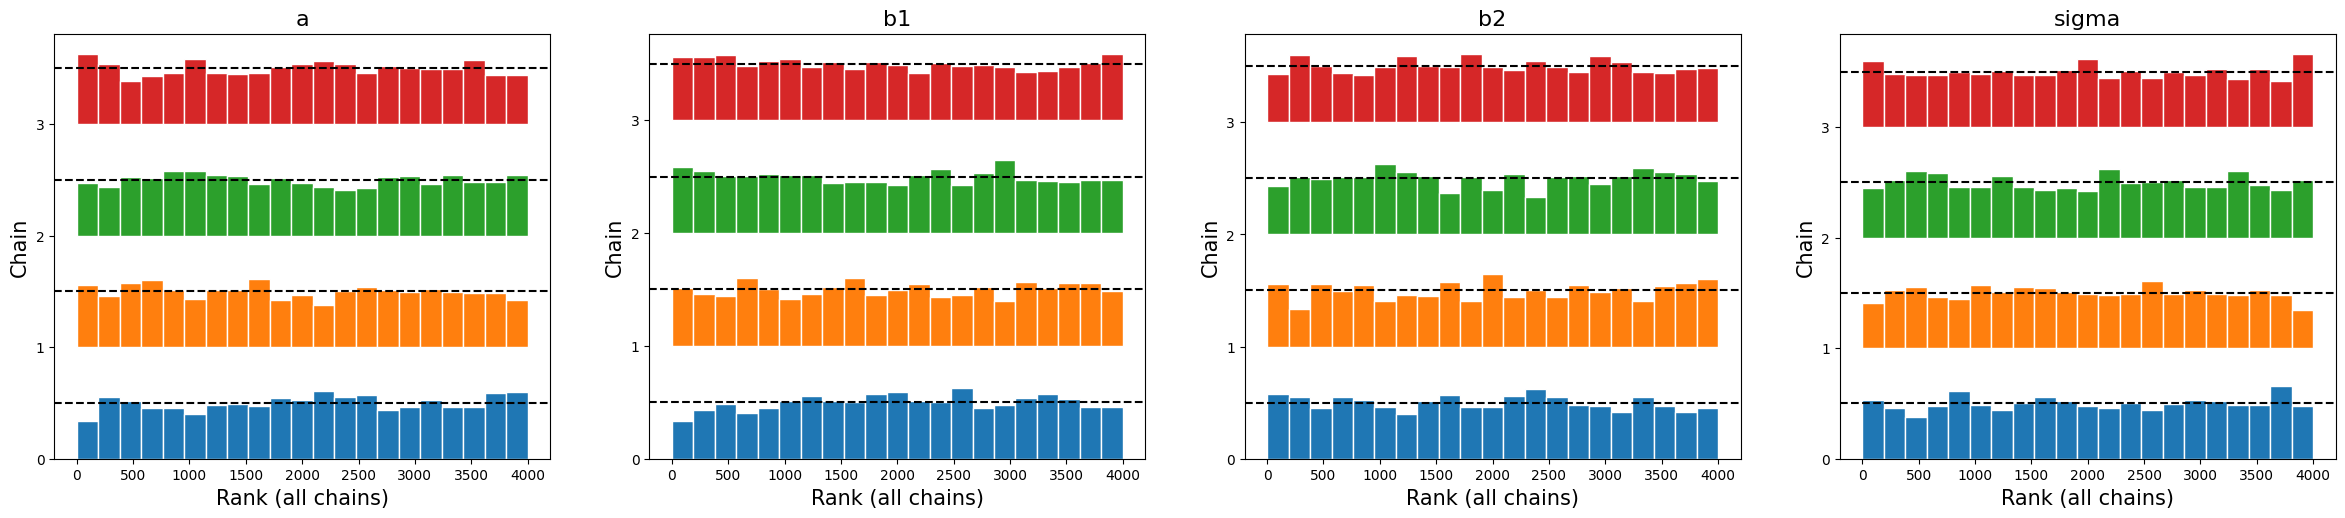

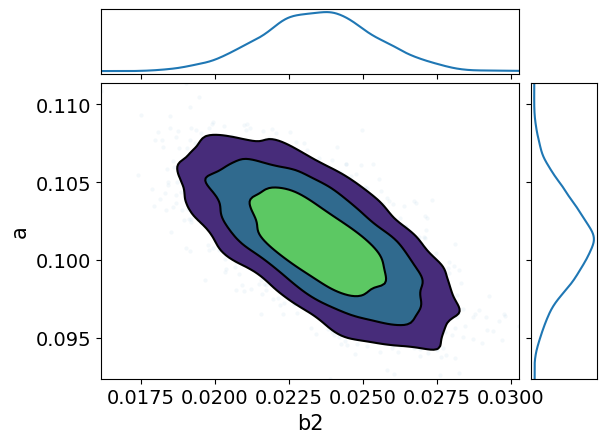

In [10]:
# we have a different mu for every datapoint
az.plot_rank(trace_1_2, varnames)
# zoom into interesting properties:
ax = az.plot_pair(
    trace_1_2,
    var_names=["b2", "a"],
    marginals=True,
    kind=["scatter", "kde"],
    scatter_kwargs={"color": "C0", "alpha": 0.05},
    marginal_kwargs={"kind": "kde", "color": "C0"},
    kde_kwargs={"contour_kwargs": {"colors": "k", 'alpha': 1}});

In [11]:
mu_pred_1_2 = trace_1_2.posterior["mu"]
with m_1_2:
    math_pred_1_2 = pm.sample_posterior_predictive(trace_1_2)

Output()

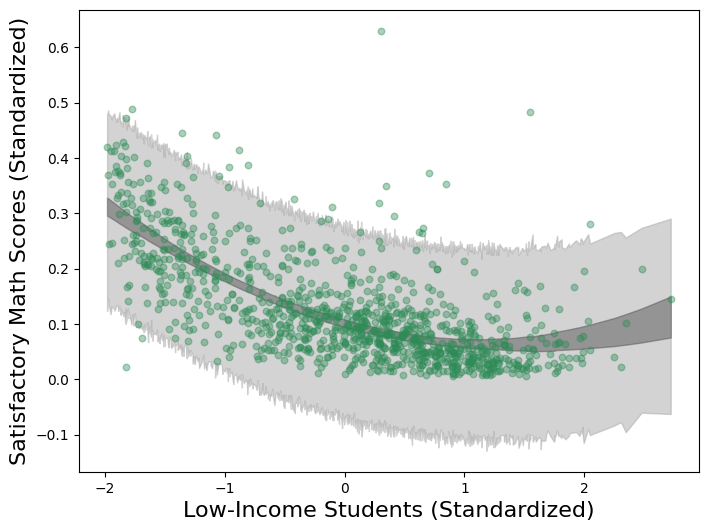

In [12]:
plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_1_2, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_1_2.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.plot([],[], color="darkgrey", label="μ")
plt.plot([],[], color="lightgrey", label="89% Interval of μ")
plt.xlabel("Low-Income Students (Standardized)", fontsize=16)
plt.ylabel("Satisfactory Math Scores (Standardized)", fontsize=16)
plt.show()

### Cubic Model

In [13]:
with pm.Model() as m_1_3:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    b3 = pm.Normal("b3", mu=0, sigma=0.01)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s + b3 * low_inc_perc3_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    trace_1_3 = pm.sample(chains=4)

Output()

In [14]:
az.summary(trace_1_3, varnames)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.100,0.003,0.095,0.105,0.0,0.0,2407.0,2778.0,1.0
b1,-0.055,0.004,-0.063,-0.046,0.0,0.0,2146.0,2003.0,1.0
b2,0.024,0.002,0.020,0.027,0.0,0.0,2580.0,2616.0,1.0
b3,-0.002,0.002,-0.005,0.001,0.0,0.0,2322.0,2471.0,1.0
sigma,0.068,0.001,0.065,0.070,0.0,0.0,4024.0,2965.0,1.0


array([[<Axes: title={'center': 'a'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'b1'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'b2'}, xlabel='Rank (all chains)', ylabel='Chain'>],
       [<Axes: title={'center': 'b3'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>,
        <Axes: >]], dtype=object)

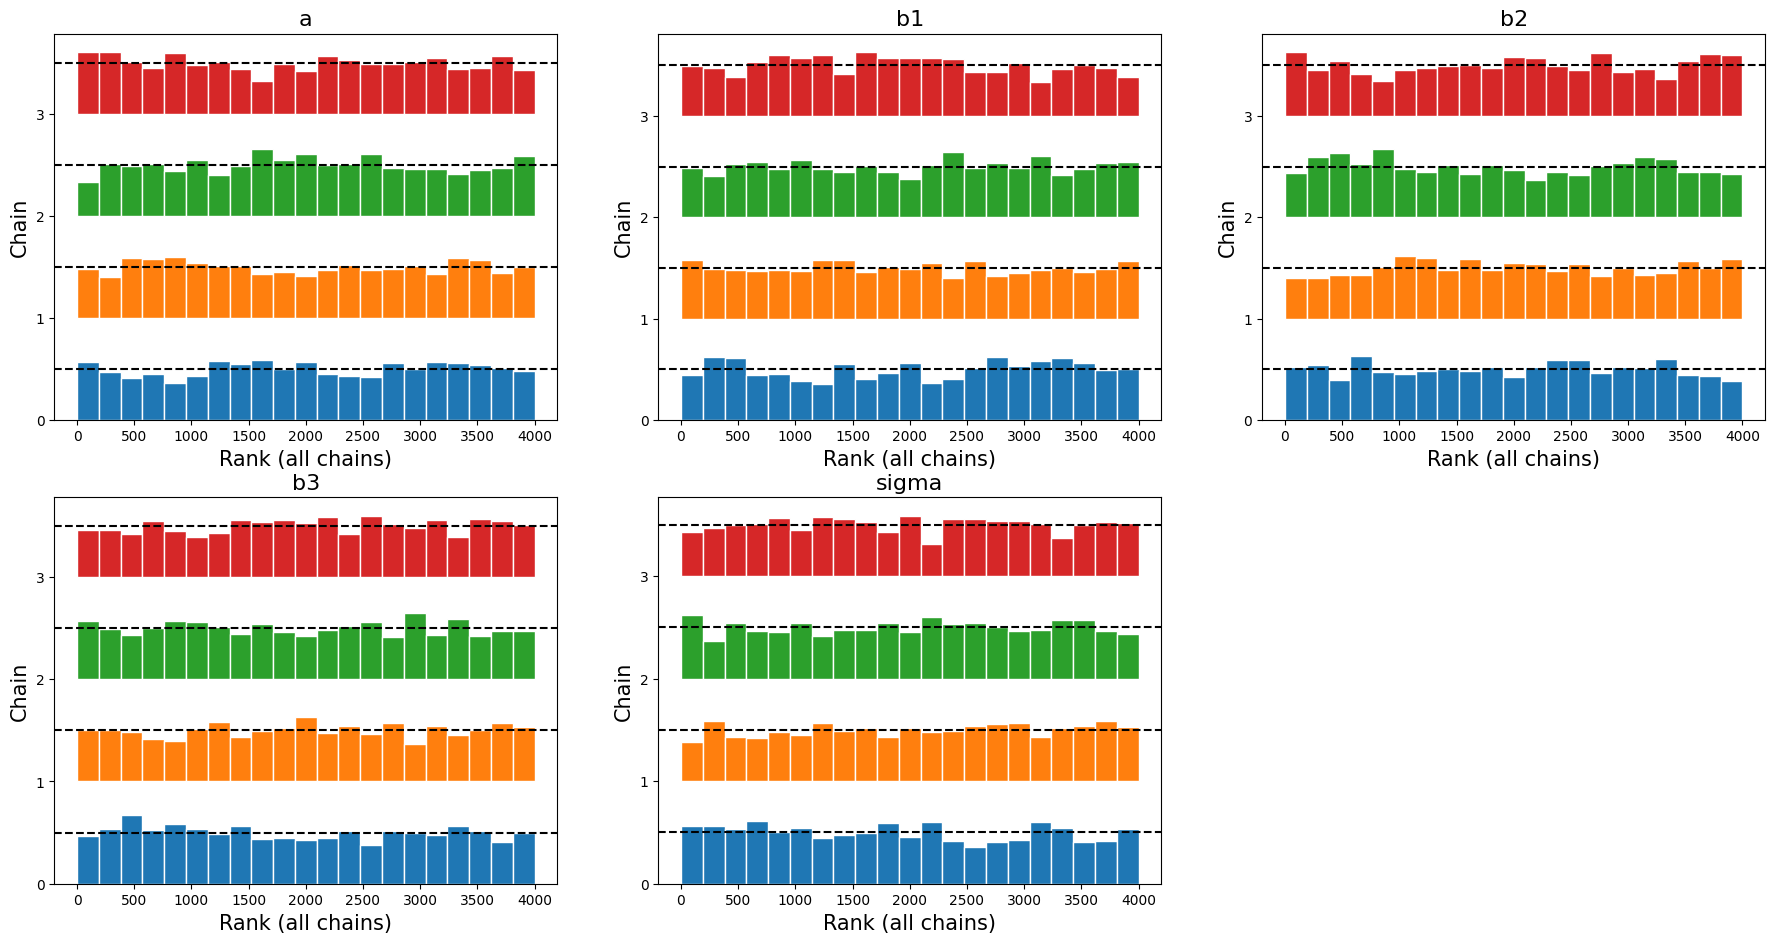

In [15]:
az.plot_rank(trace_1_3, varnames)

Output()

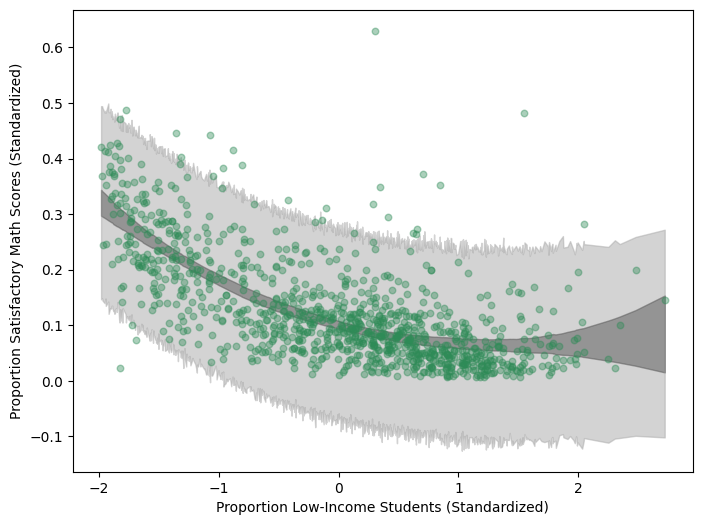

In [16]:
mu_pred_1_3 = trace_1_3.posterior["mu"]
with m_1_3:
    math_pred_1_3 = pm.sample_posterior_predictive(trace_1_3)
plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_1_3, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_1_3.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.plot([],[], color="darkgrey", label="μ")
plt.plot([],[], color="lightgrey", label="89% Interval of μ")
plt.xlabel("Proportion Low-Income Students (Standardized)")
plt.ylabel("Proportion Satisfactory Math Scores (Standardized)")
plt.show()

## Model 4


-     MODEL 4     -


Output()

Output()

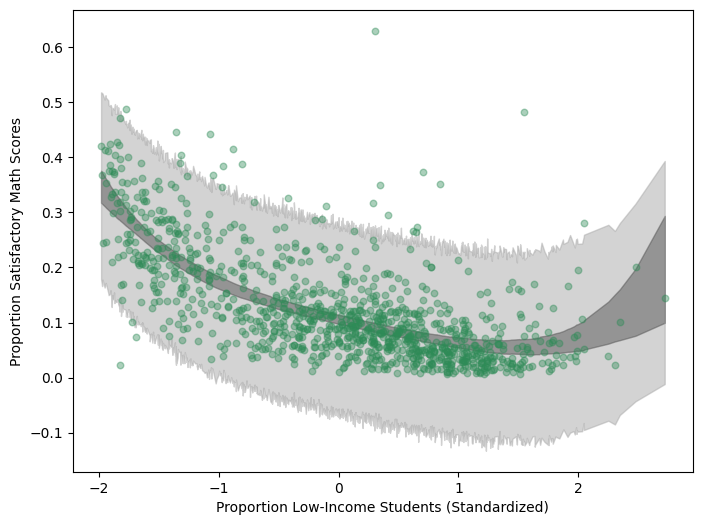

In [17]:
# degree 4
print("\n-     MODEL 4     -")
with pm.Model() as m_n_4:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    b3 = pm.Normal("b3",mu=0, sigma=0.01)
    b4 = pm.Normal("b4", mu=0, sigma=0.005)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s +
                                  b3 * low_inc_perc3_s + b4 * low_inc_perc4_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    trace_n_4 = pm.sample(chains=4, tune=1000, target_accept=0.9)

# posterior predictive and plot for model 4
mu_pred_st_4 = trace_n_4.posterior["mu"]
with m_n_4:
    math_pred_st_4 = pm.sample_posterior_predictive(trace_n_4)

plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_st_4, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_st_4.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.xlabel("Proportion Low-Income Students (Standardized)")
plt.ylabel("Proportion Satisfactory Math Scores")
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.106,0.003,0.100,0.112,0.0,0.0,2356.0,2684.0,1.0
b1,-0.050,0.004,-0.059,-0.042,0.0,0.0,2297.0,2382.0,1.0
b2,0.007,0.005,-0.002,0.016,0.0,0.0,1821.0,2188.0,1.0
b3,-0.005,0.002,-0.008,-0.001,0.0,0.0,2283.0,2118.0,1.0
b4,0.005,0.001,0.002,0.007,0.0,0.0,1866.0,2317.0,1.0
sigma,0.067,0.001,0.064,0.070,0.0,0.0,3482.0,2539.0,1.0


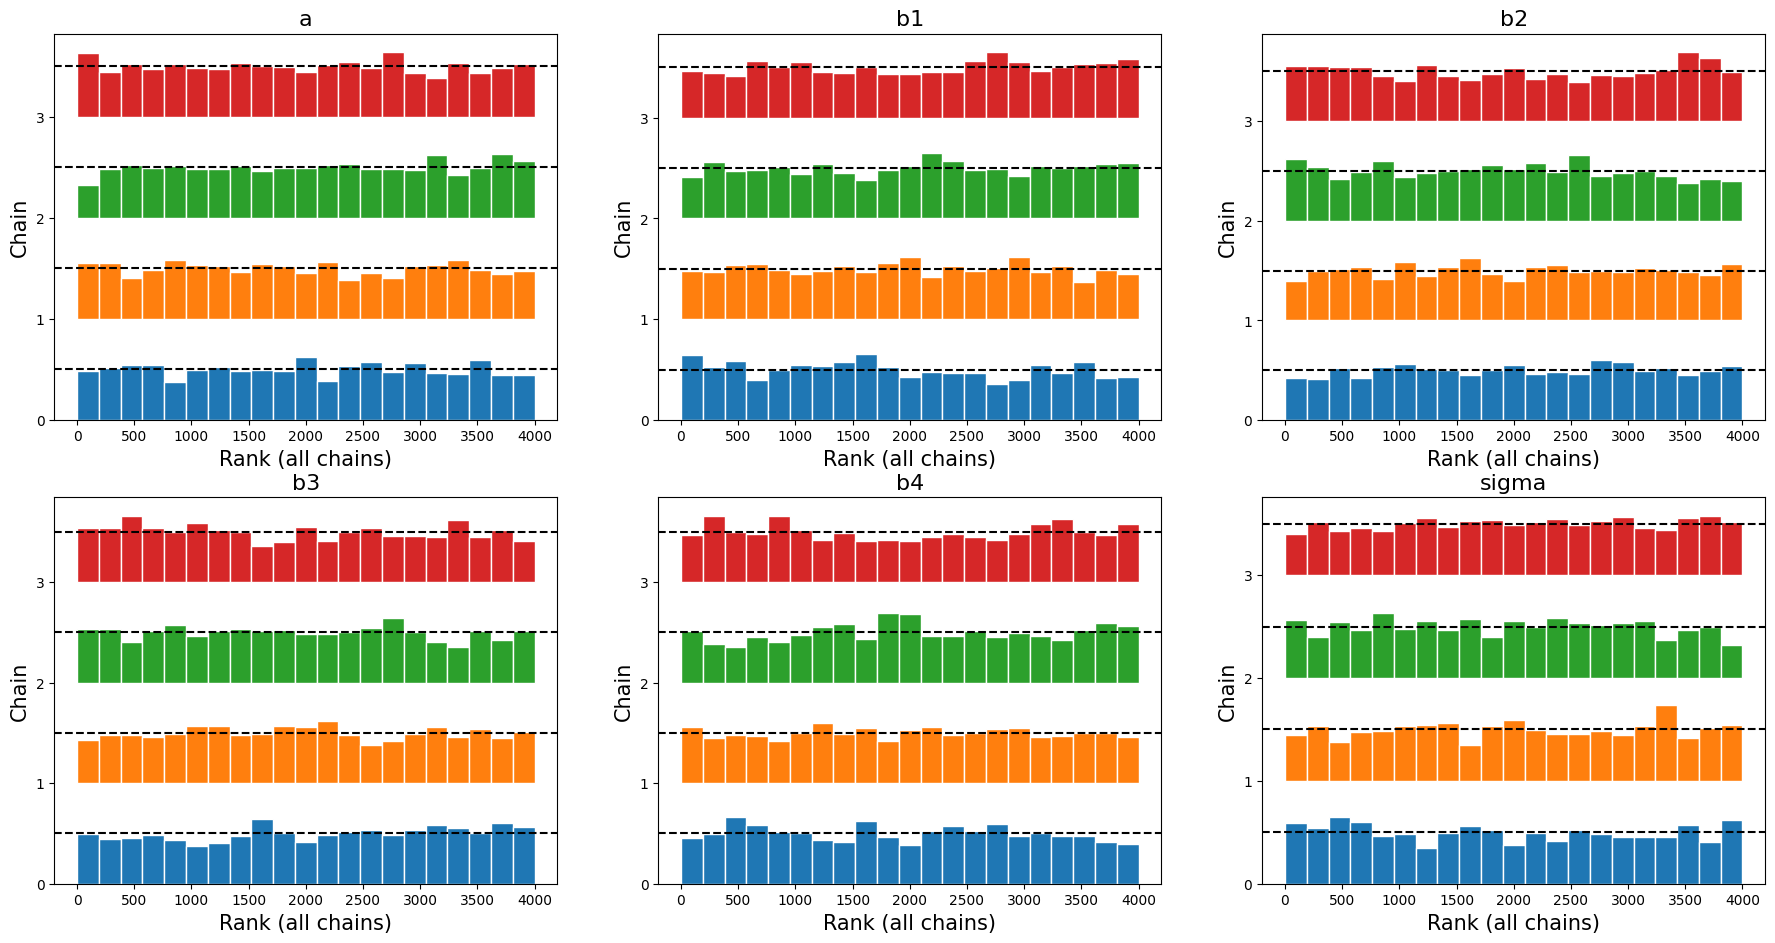

In [18]:
az.plot_rank(trace_n_4, varnames)
az.summary(trace_n_4, varnames)

## Model 5


-     MODEL 5     -


Output()

Output()

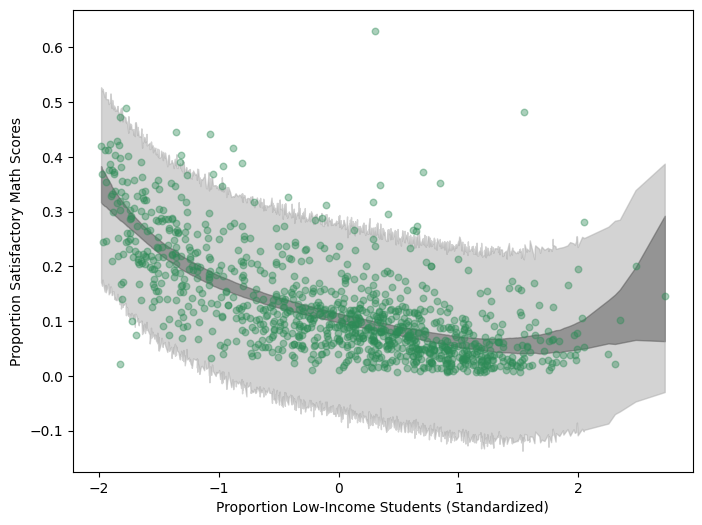

In [19]:
# degree 5
print("\n-     MODEL 5     -")
with pm.Model() as m_n_5:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    b3 = pm.Normal("b3", mu=0, sigma=0.01)
    b4 = pm.Normal("b4",mu=0, sigma=0.005)
    b5 = pm.Normal("b5", mu=0, sigma=0.001)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s +
                                  b3 * low_inc_perc3_s + b4 * low_inc_perc4_s +
                                  b5 * low_inc_perc5_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    trace_n_5 = pm.sample(chains=4, tune=1000, target_accept=0.9)

# posterior predictive and plot for model 5
mu_pred_st_5 = trace_n_5.posterior["mu"]
with m_n_5:
    math_pred_st_5 = pm.sample_posterior_predictive(trace_n_5)

plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_st_5, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_st_5.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.xlabel("Proportion Low-Income Students (Standardized)")
plt.ylabel("Proportion Satisfactory Math Scores")
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.106,0.003,0.100,0.112,0.0,0.0,2386.0,2616.0,1.0
b1,-0.051,0.005,-0.061,-0.042,0.0,0.0,2048.0,2413.0,1.0
b2,0.006,0.005,-0.004,0.016,0.0,0.0,1823.0,1908.0,1.0
b3,-0.004,0.004,-0.011,0.003,0.0,0.0,1677.0,2205.0,1.0
b4,0.005,0.002,0.002,0.008,0.0,0.0,1897.0,1856.0,1.0
b5,-0.000,0.001,-0.002,0.001,0.0,0.0,1777.0,2306.0,1.0
sigma,0.067,0.001,0.064,0.070,0.0,0.0,3237.0,2775.0,1.0


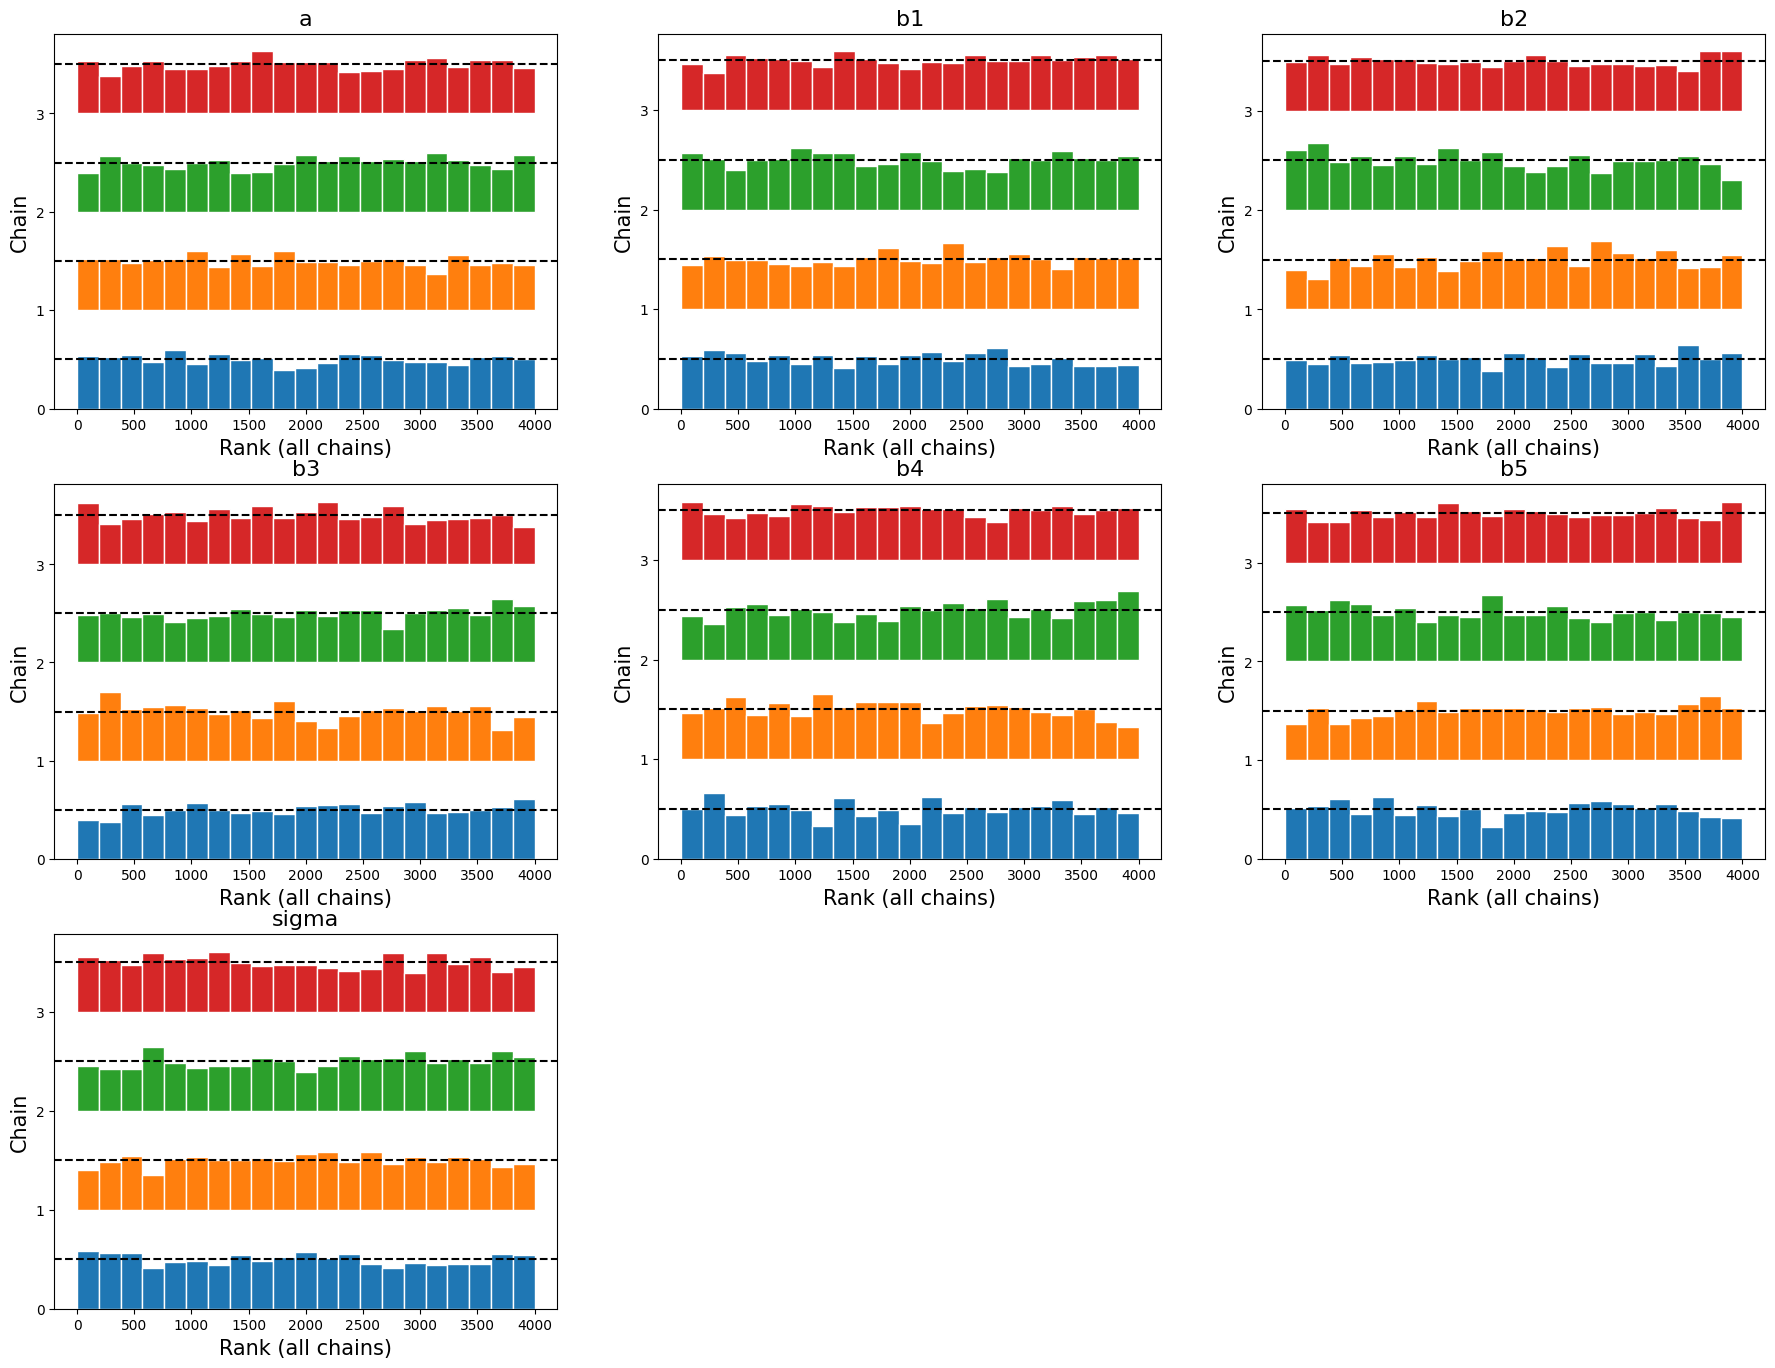

In [20]:
az.plot_rank(trace_n_5, varnames)
az.summary(trace_n_5, varnames)

## Model 6


-     MODEL 6     -


Output()

Output()

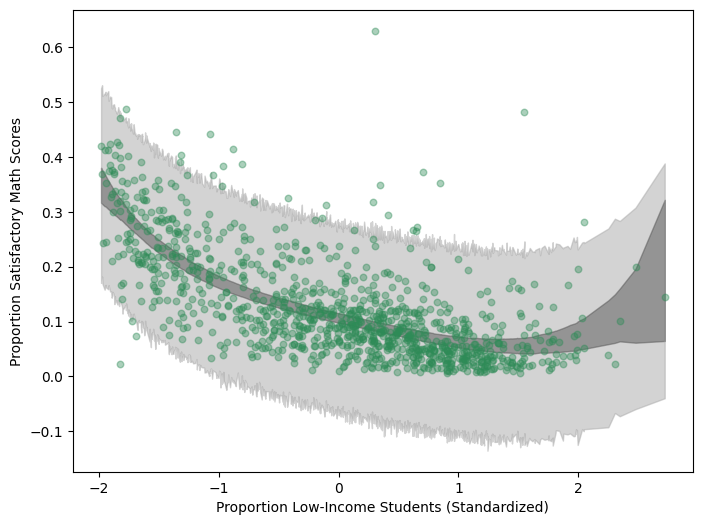

In [21]:
# degree 6
print("\n-     MODEL 6     -")
with pm.Model() as m_n_6:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    b3 = pm.Normal("b3", mu=0, sigma=0.01)
    b4 = pm.Normal("b4", mu=0, sigma=0.005)
    b5 = pm.Normal("b5", mu=0, sigma=0.001)
    b6 = pm.Normal("b6", mu=0, sigma=0.0005)
    sigma = pm.Uniform("sigma", lower=0, upper=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s +
                                  b3 * low_inc_perc3_s + b4 * low_inc_perc4_s +
                                  b5 * low_inc_perc5_s + b6 * low_inc_perc6_s)
    score_dist_st = pm.Normal("score_dist_st", mu=mu, sigma=sigma, observed=math_scores)
    trace_n_6 = pm.sample(chains=4, tune=1000, target_accept=0.9)

# posterior predictive and plot for model 6
mu_pred_st_6 = trace_n_6.posterior["mu"]
with m_n_6:
    math_pred_st_6 = pm.sample_posterior_predictive(trace_n_6)

plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_st_6, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_st_6.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.xlabel("Proportion Low-Income Students (Standardized)")
plt.ylabel("Proportion Satisfactory Math Scores")
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.106,0.003,0.100,0.112,0.0,0.0,2574.0,2596.0,1.0
b1,-0.051,0.005,-0.060,-0.041,0.0,0.0,2345.0,2419.0,1.0
b2,0.007,0.006,-0.005,0.018,0.0,0.0,2001.0,2407.0,1.0
b3,-0.003,0.004,-0.011,0.003,0.0,0.0,2076.0,2158.0,1.0
b4,0.005,0.003,0.000,0.010,0.0,0.0,1943.0,2173.0,1.0
b5,-0.000,0.001,-0.002,0.001,0.0,0.0,2264.0,2173.0,1.0
b6,0.000,0.000,-0.001,0.001,0.0,0.0,2259.0,2499.0,1.0
sigma,0.067,0.001,0.064,0.070,0.0,0.0,2955.0,2187.0,1.0


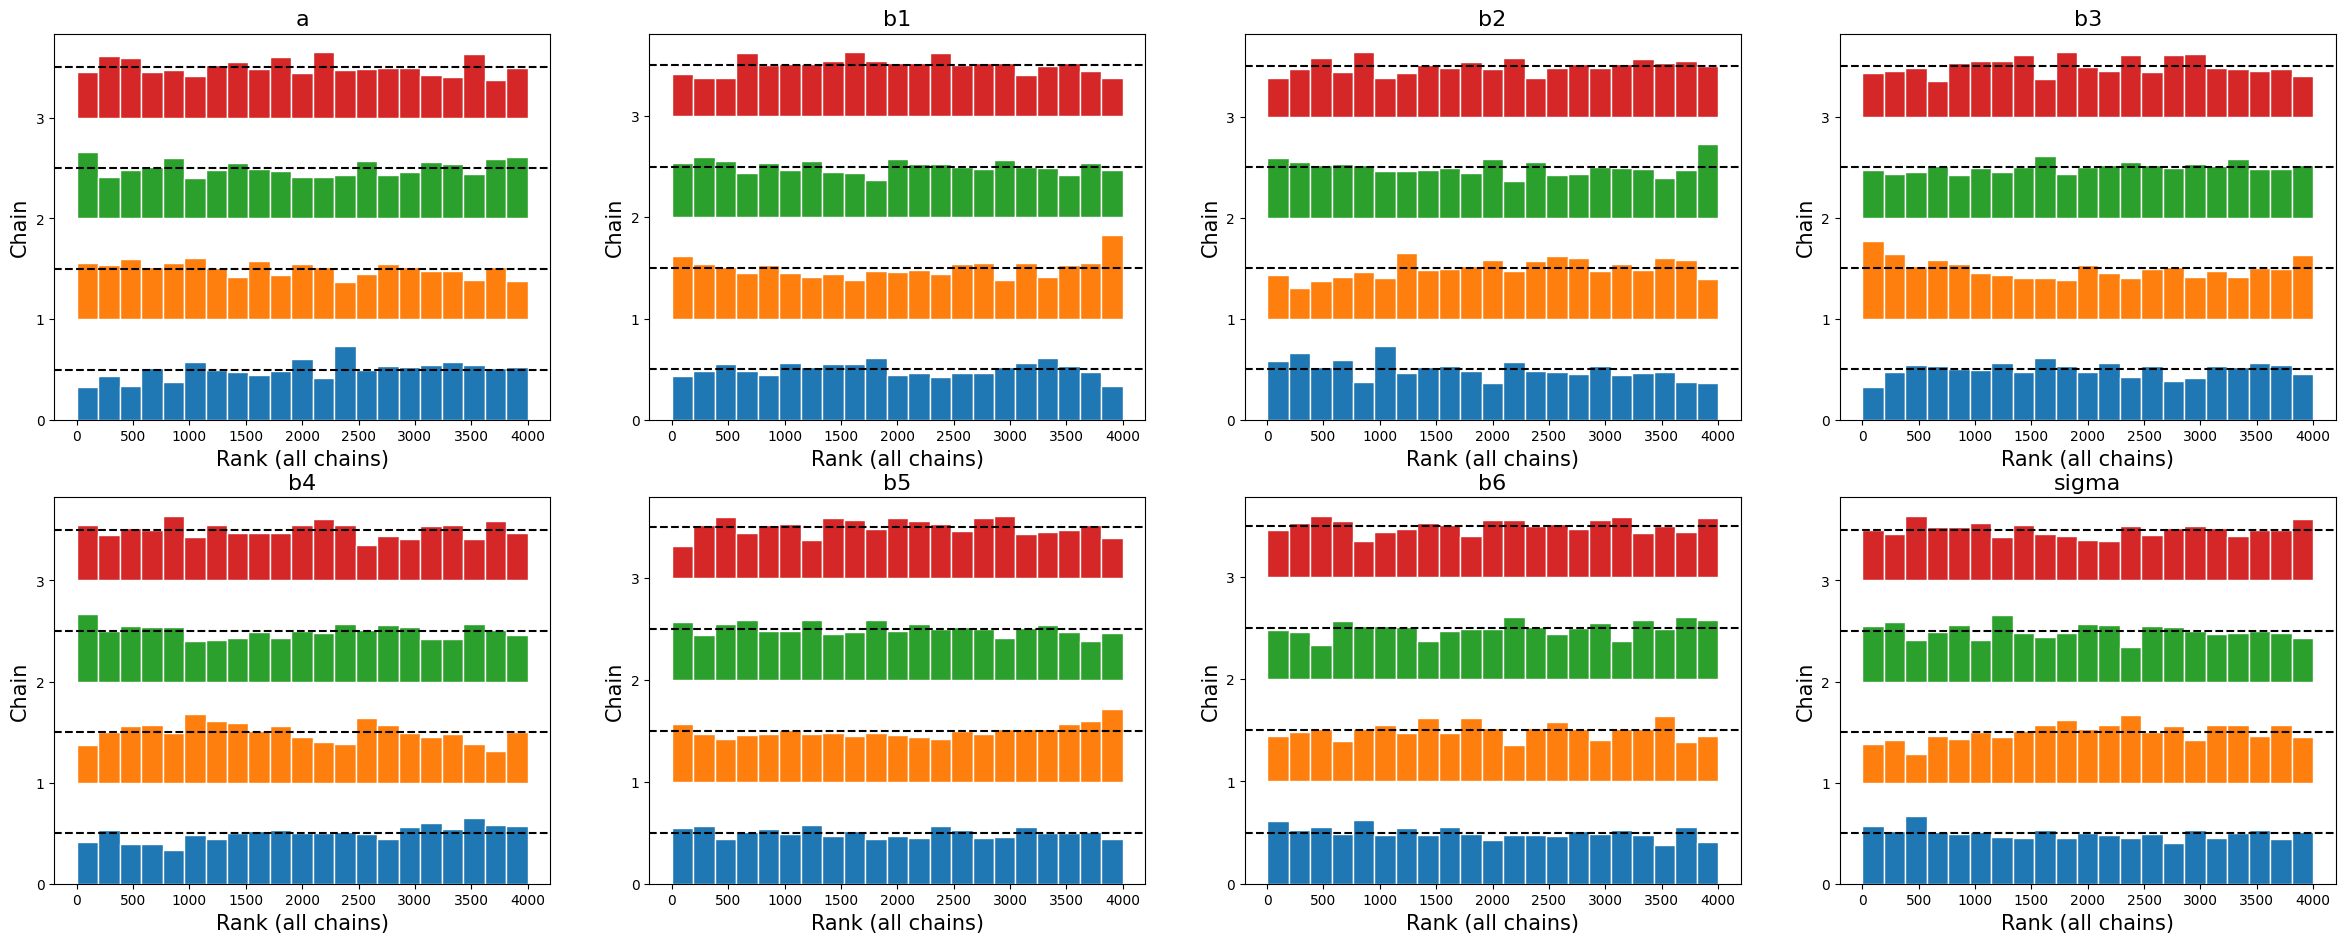

In [22]:
az.plot_rank(trace_n_6, varnames)
az.summary(trace_n_6, varnames)

In [23]:
# compute log likelihood
with m_1_1:
    pm.compute_log_likelihood(trace_1_1)
with m_1_2:
    pm.compute_log_likelihood(trace_1_2)
with m_1_3:
    pm.compute_log_likelihood(trace_1_3)
with m_n_4:
  pm.compute_log_likelihood(trace_n_4)
with m_n_5:
  pm.compute_log_likelihood(trace_n_5)
with m_n_6:
  pm.compute_log_likelihood(trace_n_6)


Output()

Output()

Output()

Output()

Output()

Output()

          rank     elpd_loo      p_loo  elpd_diff        weight         se  \
4 Params     0  1349.896720   9.805592   0.000000  8.929163e-01  49.810213   
5 Params     1  1349.728696  10.037191   0.168024  0.000000e+00  49.694572   
6 Params     2  1349.294061  10.519687   0.602660  0.000000e+00  49.767664   
2 Params     3  1343.885629   7.452855   6.011091  6.480519e-16  48.966066   
3 Params     4  1343.565740   8.700646   6.330980  0.000000e+00  48.982458   
1 Params     5  1274.700523   5.801444  75.196197  1.070837e-01  43.753945   

                dse  warning scale  
4 Params   0.000000    False   log  
5 Params   0.289137    False   log  
6 Params   0.313272    False   log  
2 Params   4.292647    False   log  
3 Params   3.650504    False   log  
1 Params  16.142205    False   log  


<Axes: xlabel='elpd_loo (log)', ylabel='ranked models'>

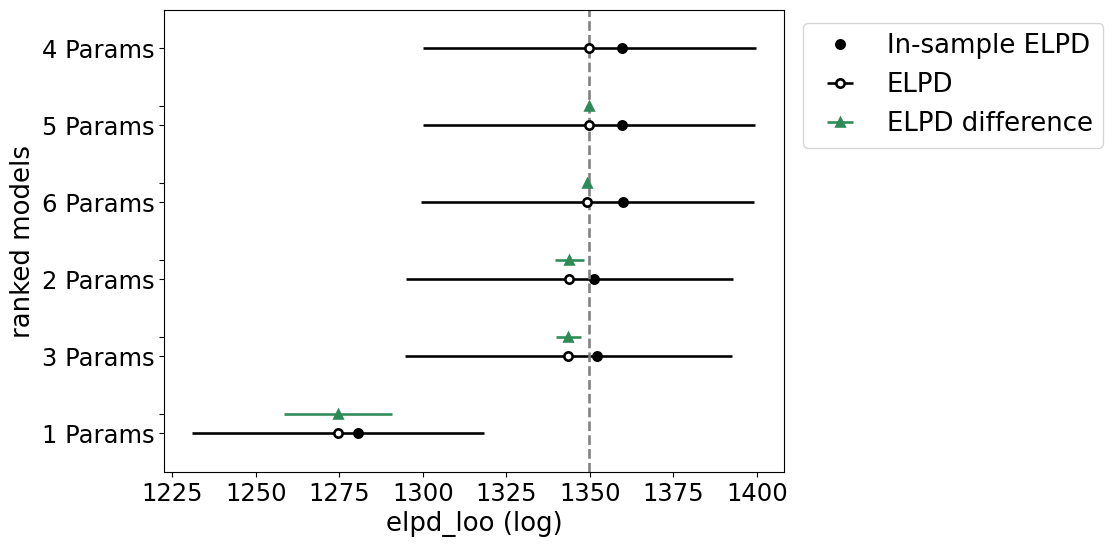

In [24]:
psis_comp_all = az.compare({'1 Params': trace_1_1, '2 Params': trace_1_2, '3 Params': trace_1_3, '4 Params': trace_n_4, '5 Params': trace_n_5, '6 Params': trace_n_6}, ic='loo')
print(psis_comp_all)
az.plot_compare(psis_comp_all,plot_ic_diff=True, insample_dev=True, title=False, plot_kwargs = {'color_dse': "seagreen"}, figsize=(8,6), legend=True)

In [25]:
# compute 99% confidence intervals
compare_mods = ['5 Params', '6 Params', '2 Params', '3 Params', '1 Params']

dict_99 = {}
for mod in compare_mods:
  crosses = False
  upper = psis_comp_all['elpd_diff'][mod] + 2.576 * psis_comp_all['dse'][mod]
  lower = psis_comp_all['elpd_diff'][mod] - 2.576 * psis_comp_all['dse'][mod]
  if lower < 0:
    crosses = True
  dict_99[mod] = [float(lower), float(upper), crosses]

mod_df = pd.DataFrame(dict_99).T
mod_df.columns = ['Lower', 'Upper', 'Crosses']
mod_df

,Lower,Upper,Crosses
5 Params,-0.576793,0.91284,True
6 Params,-0.204328,1.409647,True
2 Params,-5.046767,17.06895,True
3 Params,-3.072717,15.734677,True
1 Params,33.613877,116.778518,False


## Student T Model

In [26]:
with pm.Model() as m_s_2:
    a = pm.Beta("a", alpha=2, beta=2)
    b1 = pm.Normal("b1", mu=-0.05, sigma=0.1)
    b2 = pm.Normal("b2", mu=0, sigma=0.05)
    nu = pm.HalfNormal('nu', sigma=30)
    sigma = pm.Beta("sigma", alpha=1, beta=1)
    mu = pm.Deterministic("mu", a + b1 * low_inc_perc_s + b2 * low_inc_perc2_s)
    score_dist_st = pm.StudentT("score_dist_st", nu=nu, mu=mu, sigma=sigma, observed=math_scores)
    trace_s_2 = pm.sample(chains=4, tune=1000, target_accept=0.9)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.093,0.002,0.088,0.097,0.000,0.000,2949.0,2918.0,1.00
b1,-0.063,0.002,-0.066,-0.059,0.000,0.000,3674.0,2751.0,1.01
b2,0.024,0.002,0.021,0.027,0.000,0.000,2971.0,2424.0,1.00
nu,3.437,0.423,2.688,4.224,0.007,0.007,3255.0,3166.0,1.00
sigma,0.045,0.002,0.042,0.049,0.000,0.000,3121.0,2859.0,1.00


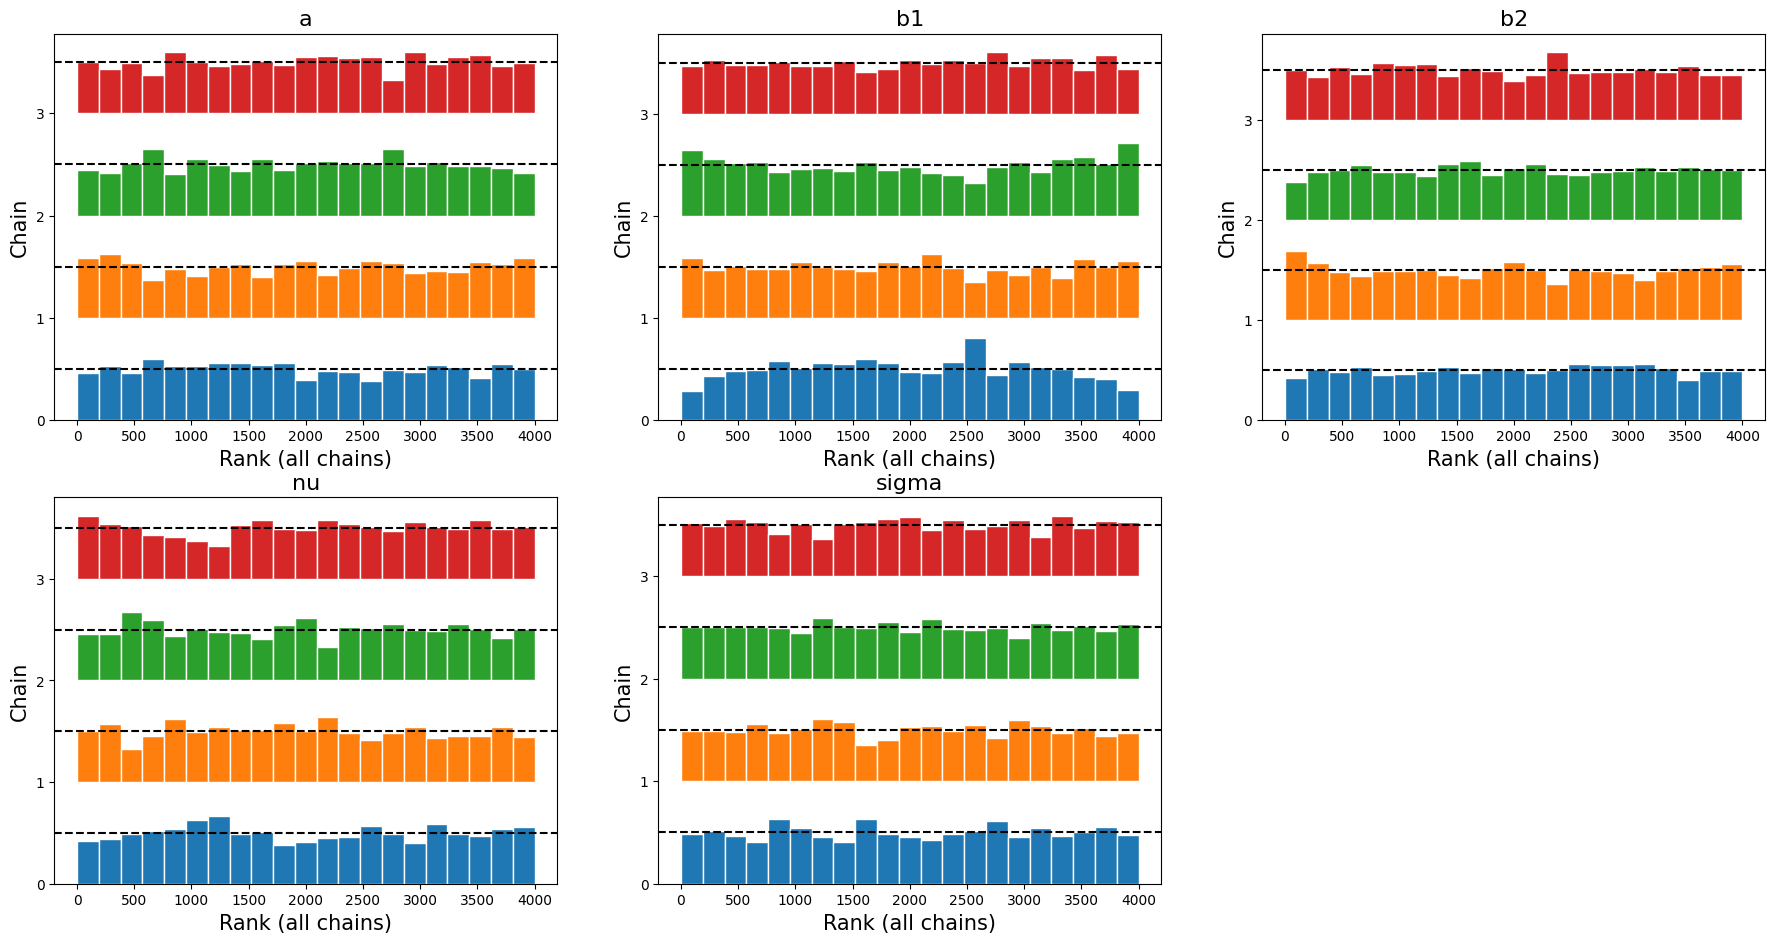

In [27]:
az.summary(trace_s_2, varnames)
az.plot_rank(trace_s_2, varnames)
az.summary(trace_s_2, varnames)

Output()

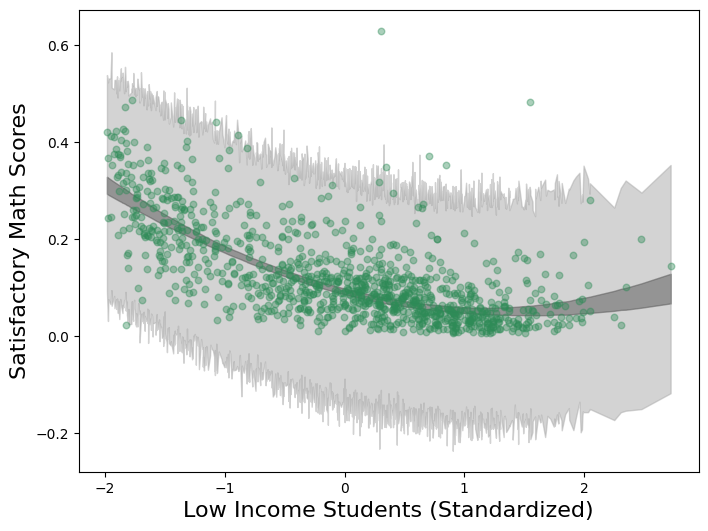

In [28]:
mu_pred_st = trace_s_2.posterior["mu"]
with m_s_2:
    math_pred_st = pm.sample_posterior_predictive(trace_s_2)

plt.figure(figsize=(8, 6))
ax = az.plot_hdi(low_inc_perc_s, mu_pred_st, smooth=False, hdi_prob=0.99, color="black")
az.plot_hdi(low_inc_perc_s, math_pred_st.posterior_predictive["score_dist_st"], hdi_prob=0.99, ax=ax, smooth=False, color="darkgrey")
plt.scatter(low_inc_perc_s, math_scores, c="seagreen", s=22, alpha=0.4, label="Data")
plt.plot([],[], color="darkgrey", label="μ")
plt.plot([],[], color="lightgrey", label="89% Interval of μ")
plt.xlabel("Low Income Students (Standardized)", fontsize=16)
plt.ylabel("Satisfactory Math Scores", fontsize=16)
plt.show()

In [29]:
with m_s_2:
  pm.compute_log_likelihood(trace_s_2)

Output()

           rank     elpd_loo     p_loo  elpd_diff    weight         se  \
Student T     0  1343.885629  7.452855   0.000000  0.908916  48.966066   
Normal        1  1274.700523  5.801444  69.185106  0.091084  43.753945   

                 dse  warning scale  
Student T   0.000000    False   log  
Normal     14.876572    False   log  



<Axes: xlabel='elpd_loo (log)', ylabel='ranked models'>

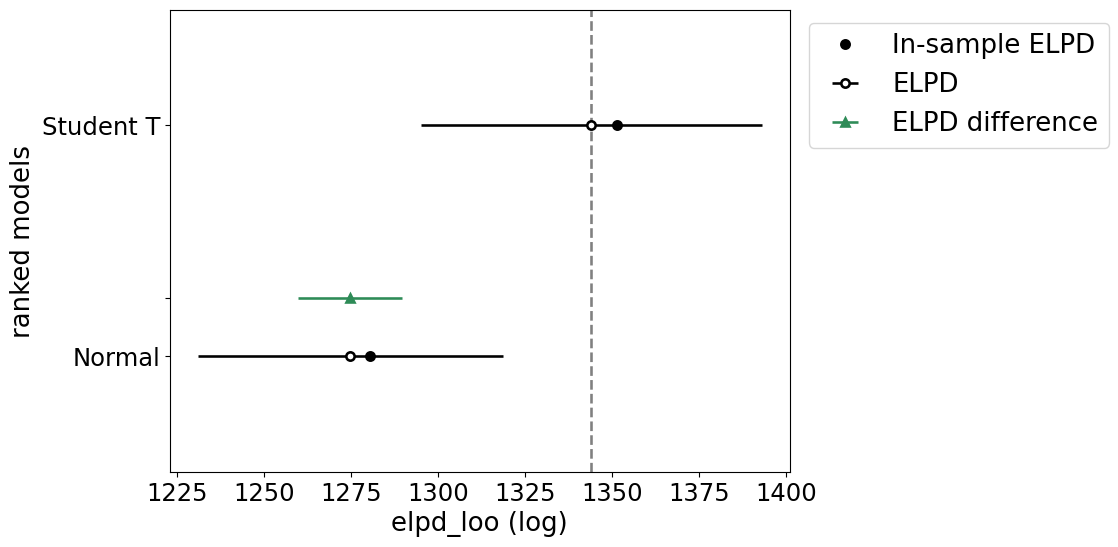

In [30]:
psis_comp_fin = az.compare({'Normal': trace_1_1, 'Student T': trace_1_2}, ic='loo')
print(psis_comp_fin)
print()

az.plot_compare(psis_comp_fin,plot_ic_diff=True, insample_dev=True, title=False, plot_kwargs = {'color_dse': "seagreen"}, figsize=(8,6), legend=True)


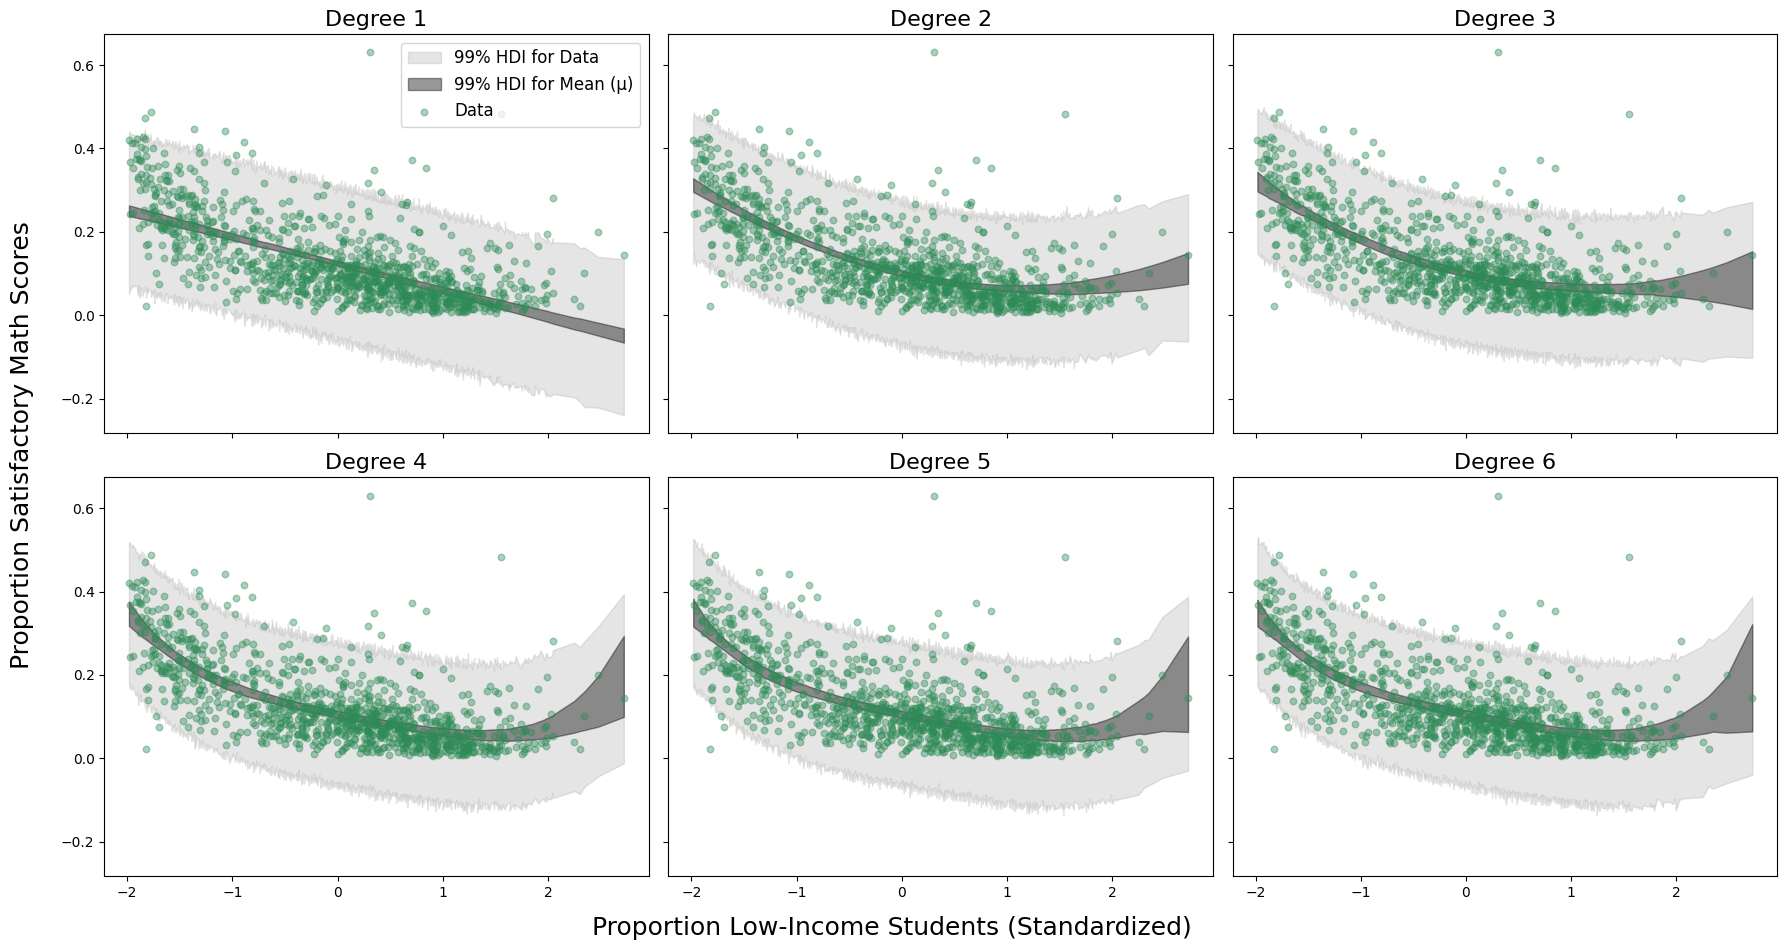

In [31]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mu_preds = [mu_pred_1_1, mu_pred_1_2, mu_pred_1_3, mu_pred_st_4, mu_pred_st_5, mu_pred_st_6]
math_preds = [math_pred_1_1, math_pred_1_2, math_pred_1_3, math_pred_st_4, math_pred_st_5, math_pred_st_6]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)


axes_flat = axes.flatten()
# add to each subplot
for i in range(len(mu_preds)):
    ax = axes_flat[i]

    # get data
    mu_pred = mu_preds[i]
    math_pred = math_preds[i]

    # 99% HDI for the posterior predictive
    az.plot_hdi(
        low_inc_perc_s,
        math_pred.posterior_predictive["score_dist_st"],
        hdi_prob=0.99,
        ax=ax,
        smooth=False,
        color="darkgrey",
        fill_kwargs={'alpha': 0.3, 'label': '99% HDI for Data'}
    )

    # 99% HDI for the mean
    az.plot_hdi(
        low_inc_perc_s,
        mu_pred,
        hdi_prob=0.99,
        ax=ax,
        smooth=False,
        color="black",
        fill_kwargs={'alpha': 0.4, 'label': '99% HDI for Mean (μ)'}
    )

    # scatterplots
    ax.scatter(
        low_inc_perc_s,
        math_scores,
        c="seagreen",
        s=22,
        alpha=0.4,
        label="Data"
    )

    # title for subplots
    ax.set_title(f"Degree {i+1}", fontsize=16)

    # only 1 legend
    if i == 0:
        ax.legend(fontsize=12)

fig.text(
    0.5,
    0.01,
    'Proportion Low-Income Students (Standardized)',
    ha='center',
    fontsize=18
)
fig.text(
    0.01,
    0.5,
    'Proportion Satisfactory Math Scores',
    va='center',
    rotation='vertical',
    fontsize=18
)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()
